
Top 15 Feature Importances (Random Forest):
satisfaction_level       0.2724
number_project           0.1385
last_evaluation          0.1105
tenure_years             0.1020
time_spend_company       0.1014
average_montly_hours     0.1009
low_satisfaction_flag    0.0600
high_hours_flag          0.0236
tenure_band_3-5          0.0214
tenure_band_0-2          0.0114
early_tenure_flag        0.0101
tenure_band_6-10         0.0090
work_accident            0.0062
salary_low               0.0054
salary_high              0.0038
dtype: float64

Top 15 Feature Importances (Permutation):
satisfaction_level       0.1725
last_evaluation          0.1161
number_project           0.1127
average_montly_hours     0.1089
time_spend_company       0.0438
tenure_years             0.0395
high_hours_flag          0.0039
department_technical     0.0030
low_satisfaction_flag    0.0029
salary_low               0.0021
salary_medium            0.0016
department_support       0.0013
work_accident            0.0013
d

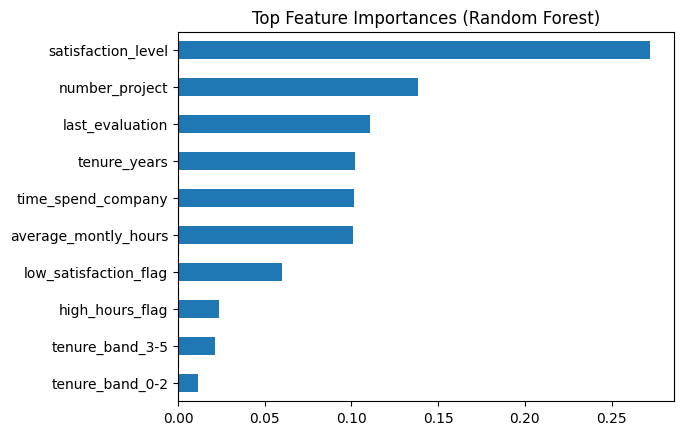

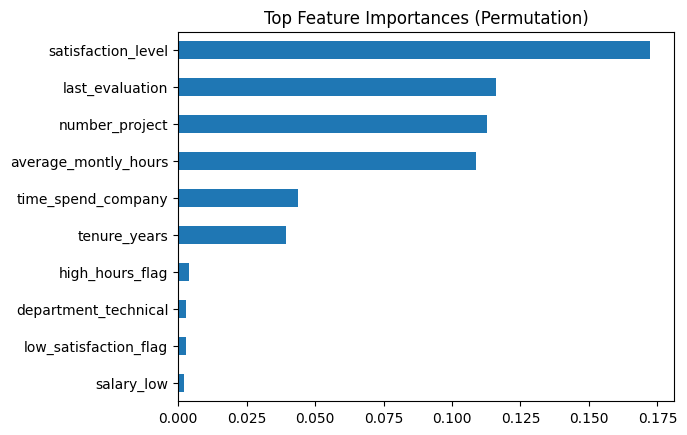

In [7]:
# 1. Imports
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt

# 2. Load dataset
file_path = "/content/drive/MyDrive/Colab Notebooks/Initial_Modeling_Dataset.csv"
df = pd.read_csv(file_path)

# 3. Define target and features
target = "attrition_flag"
X = df.drop(columns=[target])
y = df[target]

# 4. One-hot encode categorical variables (if not already encoded)
X = pd.get_dummies(X, drop_first=True)

# 5. Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 6. Train Random Forest model
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
model.fit(X_train, y_train)

# 7. Feature Importance (Model-based)
importances = pd.Series(model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False)

print("\nTop 15 Feature Importances (Random Forest):")
print(importances.head(15).round(4))

# 8. Permutation Importance (more reliable)
perm_importance = permutation_importance(
    model, X_test, y_test, n_repeats=10, random_state=42
)

perm_series = pd.Series(
    perm_importance.importances_mean,
    index=X.columns
).sort_values(ascending=False)

print("\nTop 15 Feature Importances (Permutation):")
print(perm_series.head(15).round(4))

# 9. Plot Top Features
top_n = 10

plt.figure()
importances.head(top_n).plot(kind="barh")
plt.title("Top Feature Importances (Random Forest)")
plt.gca().invert_yaxis()
plt.show()

plt.figure()
perm_series.head(top_n).plot(kind="barh")
plt.title("Top Feature Importances (Permutation)")
plt.gca().invert_yaxis()
plt.show()